# Integrated Gradients (IG) on the NeuroFlow encoding pipeline (Image -> fMRI)

The goal is to calculate and visualize attribution maps on the input images with respect to some metric of interest on the reconstructed fMRI betas.

# Target metric

Gradient based methods inherently rely on a target metric/loss function. No natural candidate suggests itself in the context of NeuroFlow primarily because it is a unsupervised model trained using complex loss functions.

## NeuroVAE loss function

The original fMRI VAE is trained using a composite loss function:

$\mathcal{L}_\text{VAE} = \mathcal{L}_\text{MSE} + \alpha\mathcal{L}_\text{KL} + \beta\mathcal{L}_\text{CLIP} + \lambda\mathcal{L}_\text{CYC}$

Where 
- $\mathcal{L}_\text{MSE}$ is the mean square error of the reconstructed fMRI to the ground truth
- $\mathcal{L}_\text{KL}$ is the Kullbach-Leibacher divergence between the latent posterior and its prior.
- $\mathcal{L}_\text{CLIP}$ is the SoftCLIP contrastive loss of the latent to the CLIP encoding of the corresponding stimulus image
- $\mathcal{L}_\text{CYC}$ is the SoftCLIP constrastive loss of the latent to itself when decoded and re-encoded

But for Integrated Gradients, the target metric has to be defined in an interpretable way related to the nature of the data. In case of NeuroFlow, we are dealing with session-normalized single trial beta values for brain voxels. Roughly, they indicate how much each voxel responds to a given stimulus compared with the baseline (a gray image). 

## Targeted fMRI response attribution

Before additional insights are avaiable on the attentional patters in the fMRI data, it makes most sense to consider the functional regions as the prime targets for attribution experiments. A simple start is to calculate the mean specifically on a region of interest (ROI). This will require masking the VAE output accordingly.


In [1]:
import nibabel as nib
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import os

The easiest way to integrate the masking precedure into the loss is to precompute the masks of interest on the flattend representations of the fmri data. We will extract a couple of relevant masks here and store them for use during inference. Define ROI masks. We will use all available ROIs for every fLoc experiment

In [ ]:
# we can recycle the code from the floc experiment

def get_roi_mask(roi_ids, mask_file):
    mask_img = nib.load(mask_file)
    mask_data = mask_img.get_fdata()
    roi_mask = np.isin(mask_data, roi_ids)
    return roi_mask

roi_masks = {
    'general': get_roi_mask(roi_ids=[1], mask_file='../../sample_data/roi/nsdgeneral.nii.gz'),
    'bodies': get_roi_mask(roi_ids=[1, 2, 3, 4], mask_file='../../sample_data/roi/floc-bodies.nii.gz'),
    'faces': get_roi_mask(roi_ids=[1, 2, 3, 4, 5], mask_file='../../sample_data/roi/floc-faces.nii.gz'),
    'places': get_roi_mask(roi_ids=[1, 2, 3], mask_file='../../sample_data/roi/floc-places.nii.gz'),
    'v1': get_roi_mask(roi_ids=[1, 2], mask_file='../../sample_data/roi/prf-visualrois.nii.gz'),
    'v2': get_roi_mask(roi_ids=[3, 4], mask_file='../../sample_data/roi/prf-visualrois.nii.gz'),
    'v3': get_roi_mask(roi_ids=[5, 6], mask_file='../../sample_data/roi/prf-visualrois.nii.gz'),
    'v4': get_roi_mask(roi_ids=[7], mask_file='../../sample_data/roi/prf-visualrois.nii.gz')
}

general_mask = roi_masks.pop('general')

for roi_name, roi_mask in roi_masks.items():
    roi_mask_numeric = roi_mask.astype(int)
    roi_mask_flat = roi_mask_numeric[general_mask]

    # reshape to N samples x T trials x V voxels
    roi_mask_reshaped = roi_mask_flat.reshape(1, 1, -1)

    roi_mask_tensor = torch.tensor(roi_mask_reshaped)
    torch.save(roi_mask_tensor, f'2d_masks/subject_1/mask_{roi_name}.pt')

# Input baseline (Null-input)

IG calculates the integral of the gradient along a path between a baseline condition (Null-input) and the target input. In cases of images, the black image where all pixel have value 0 is most often taken as the null input. In the context of the NSD dataset, it may also make sense to consider the null input to be the gray image (all pixel values 128) as this is what was used as a null-stimulus in the experiments. It has to be noted though, that the gray image has no special quality in the fixed CLIP encoder model. In fact, it may lie in a peculiar region of the encoding space.

In [18]:
# define and save a black and grey 425 x 425 image for use as baselines
import PIL.Image as Image

black_image = Image.new('RGB', (425, 425), color=(0, 0, 0))
grey_image = Image.new('RGB', (425, 425), color=(128, 128, 128))

black_image.save('image_data/black.png')
grey_image.save('image_data/grey.png')

Another candidate baseline is a heavily blurred version of the original image. We apply a Gaussian kernel with radius 75 to all 50 sample images from the test set:

In [19]:
# heavily blur the images for use as a baseline
from PIL import Image, ImageFilter
def blur_image(image_path, output_path, blur_radius=75):
    image = Image.open(image_path)
    blurred_image = image.filter(ImageFilter.GaussianBlur(blur_radius))
    blurred_image.save(output_path)

image_dir = "/u/fdammeier/repositories/NeuroFlow/sample_data/images"
output_dir = "/u/fdammeier/repositories/NeuroFlow/sample_data/images_blur"

import os
for filename in os.listdir(image_dir):
    if filename.endswith(".png"):
        blur_image(os.path.join(image_dir, filename), os.path.join(output_dir, filename))

The baseline has to be determined in relation to the target metric, so different combinations are tried out in order to identify potential candidates. We start by comparing simple statistics on the fMRI reconstructions of the original images, the candidate baselines and the original fMRI means.

In [2]:
# Reconstructed fMRI for the selected images
# Mean across trials (T=3) for the original zscored fMRI data
fmri_orig = torch.load("/u/fdammeier/repositories/NeuroFlow/sample_data/fmri_zscores.pt").mean(dim=1).unsqueeze(1)
# Reconstructed fMRI zscores for the same sample
fmri_recon = torch.load("/u/fdammeier/artifacts/full_inference/reconstructed_fmri.pt")
# Reconstructions of the blurred images
fmri_recon_blurred = torch.load("/u/fdammeier/artifacts/image_to_fmri_blurred/reconstructed_fmri.pt")
# Reconstruction of a gray image; repeated for easier unified downstream processing
fmri_recon_gray = torch.load("/u/fdammeier/artifacts/gray_image/reconstructed_fmri.pt").repeat(50, 1, 1)
# The shape is N samples x T = 1 trials x V voxels for all fMRI data
fmri_orig.shape, fmri_recon.shape, fmri_recon_blurred.shape, fmri_recon_gray.shape 

(torch.Size([50, 1, 15724]),
 torch.Size([50, 1, 15724]),
 torch.Size([50, 1, 15724]),
 torch.Size([50, 1, 15724]))

We are interested in the mean values across fMRI ROIs. We define the ROIs as masks.

In [3]:
mask_names = ["faces", "bodies", "places", "v1", "v2", "v3", "v4"]
masks = {name: torch.load(f"/u/fdammeier/repositories/NeuroFlow/experiments/integrated_gradients/2d_masks/subject_1/mask_{name}.pt") for name in mask_names}
masks["full"] = torch.ones_like(masks["faces"])

We define a simple mask mean metric:

In [4]:
def masked_mean(tensor, mask):
    return (tensor * mask).sum() / mask.sum()

 We use this function to populate a Pandas dataframe in the form

 | IDX | ROI | RECON     | MEAN (of means) | STD (of means) |
 | --- | --- | --------- | --------------- | -------------- |
 |   0 | v1  | original  |               0 |             .5 |

In [5]:
# Compute masked means for all masks and all types of fMRI reconstructions, storing them in a dataframe
data = []
for roi, mask in masks.items():
    for recon_name, fmri in zip(["orig", "recon", "recon_blurred", "recon_gray"], 
                                [fmri_orig, fmri_recon, fmri_recon_blurred, fmri_recon_gray]):
        means = [masked_mean(fmri[i], mask).item() for i in range(fmri.shape[0])]
        for mean_value in means:
            data.append({
                "ROI": roi,
                "RECONSTRUCTION": recon_name,
                "mean": mean_value
            })

df = pd.DataFrame(data)
df.head(5)

,ROI,RECONSTRUCTION,mean
0,faces,orig,-0.284547
1,faces,orig,-0.377731
2,faces,orig,-0.183890
3,faces,orig,0.027718
4,faces,orig,0.218401


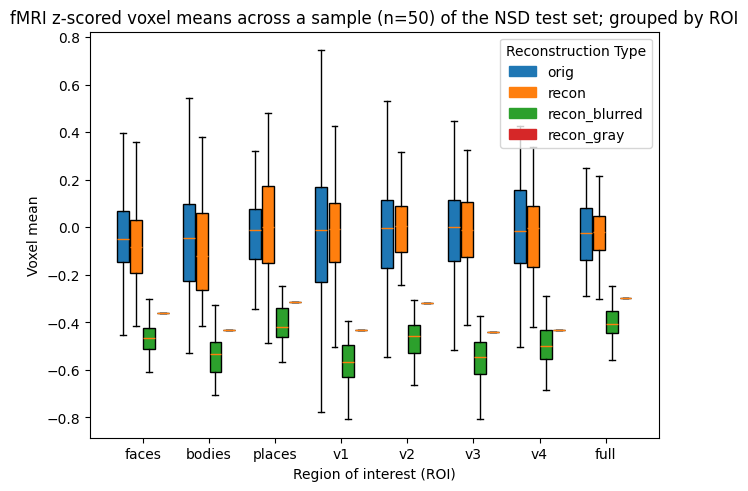

In [10]:
# Plot the results as a vertical grouped box plot
# Use ROI as the grouping variable for the boxes, use color to differentiate the reconstruction types
def plot_grouped_boxplot(df, title):
    roi_names = list(masks.keys())
    recon_names = ["orig", "recon", "recon_blurred", "recon_gray"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    x = np.arange(len(roi_names))  # the label locations
    width = 0.2  # the width of each box
    multiplier = 0

    fig, ax = plt.subplots(layout="constrained")

    for i, recon_name in enumerate(recon_names):
        offset = width * multiplier
        values = [
            df[(df["ROI"] == roi) & (df["RECONSTRUCTION"] == recon_name)]["mean"].to_numpy()
            for roi in roi_names
        ]
        bplot = ax.boxplot(
            values,
            positions=x + offset,
            widths=width * 0.9,
            patch_artist=True,
            showfliers=False,
        )
        for patch in bplot["boxes"]:
            patch.set_facecolor(colors[i % len(colors)])
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel("Voxel mean")
    ax.set_xlabel("Region of interest (ROI)")
    ax.set_title(title)
    ax.set_xticks(x + width * (len(recon_names) - 1) / 2, roi_names)
    legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i % len(colors)]) for i in range(len(recon_names))]
    ax.legend(legend_handles, recon_names, title="Reconstruction Type")

    plt.show()

plot_grouped_boxplot(df, "fMRI z-scored voxel means across a sample (n=50) of the NSD test set; grouped by ROI")

Inspecting the mean voxel values across samples, we can make a couple of observations:

- the NeuroFlow encoding pipeline captures the original fMRI statistics quite well in general, across ROIs
- both tested baselines are severely out of distribution compared with the originals, the deviation for blurred images being larger than for gray ones
- original and recon statistics are closely distributed around zero, as implied by the z-scoring of the raw voxel betas

Do we see, on this level of granularity, any interpretable change when filtering the images for categories?

In [11]:
# Manually construct two lists of indices for filtering
human_indices = [0, 4, 9, 14, 17, 19, 20, 34, 45, 47, 49]
animal_indices = [4, 6, 12, 13, 23, 25, 27, 28, 31, 37, 40, 48]

# a bit of a hack, but let's transform those to indices on the pre-calculated dataframe
# we have 8 * 4 = 32 occurences per index
human_indices_df = []
for i in range(0, 32*50, 50):
    for idx in human_indices:
        human_indices_df.append(i+idx)

animal_indices_df = []
for i in range(0, 32*50, 50):
    for idx in animal_indices:
        animal_indices_df.append(i+idx)

In [70]:
human_df = df.loc[human_indices_df]
animal_df = df.loc[animal_indices_df]

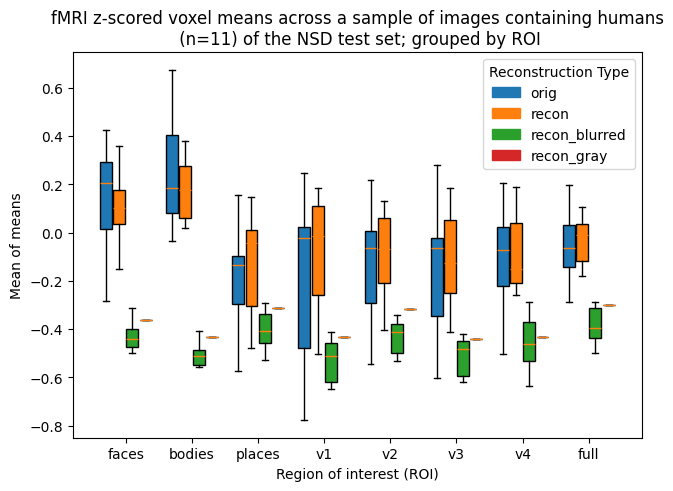

In [59]:
plot_grouped_boxplot(human_df, "fMRI z-scored voxel means across a sample of images containing humans\n (n=11) of the NSD test set; grouped by ROI")

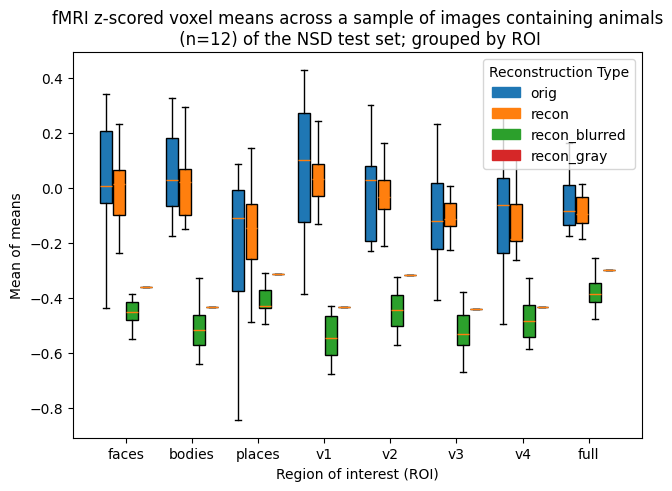

In [63]:
plot_grouped_boxplot(animal_df, "fMRI z-scored voxel means across a sample of images containing animals\n (n=12) of the NSD test set; grouped by ROI")

We extend the analysis to more complex metrices
1. ROI mean against reference
    - Non-ROI voxels
    - All voxels

In [33]:
def masked_relative_mean(data, mask):
    """This contrasts the masked mean with the mean of all unmasked voxels."""
    inverse_mask = 1 - mask
    masked_mean = (data * mask).sum() / mask.sum()
    inverse_masked_mean = (data * inverse_mask).sum() / inverse_mask.sum()

    return masked_mean - inverse_masked_mean

def masked_relative_mean_2(data, mask):
    """This constrasts the masked mean with the mean of all voxels."""
    masked_mean = (data * mask).sum() / mask.sum()
    overall_mean = data.mean()

    return masked_mean - overall_mean

In [34]:
# Compute masked means for all masks and all types of fMRI reconstructions, storing them in a dataframe
data = []
for roi, mask in masks.items():
    for recon_name, fmri in zip(["orig", "recon", "recon_blurred", "recon_gray"], 
                                [fmri_orig, fmri_recon, fmri_recon_blurred, fmri_recon_gray]):
        means = [masked_relative_mean_2(fmri[i], mask).item() for i in range(fmri.shape[0])]
        for mean_value in means:
            data.append({
                "ROI": roi,
                "RECONSTRUCTION": recon_name,
                "mean": mean_value
            })

df_relative = pd.DataFrame(data)
df_relative.head(5)

,ROI,RECONSTRUCTION,mean
0,faces,orig,0.003939
1,faces,orig,-0.182535
2,faces,orig,-0.034977
3,faces,orig,-0.213129
4,faces,orig,0.392199


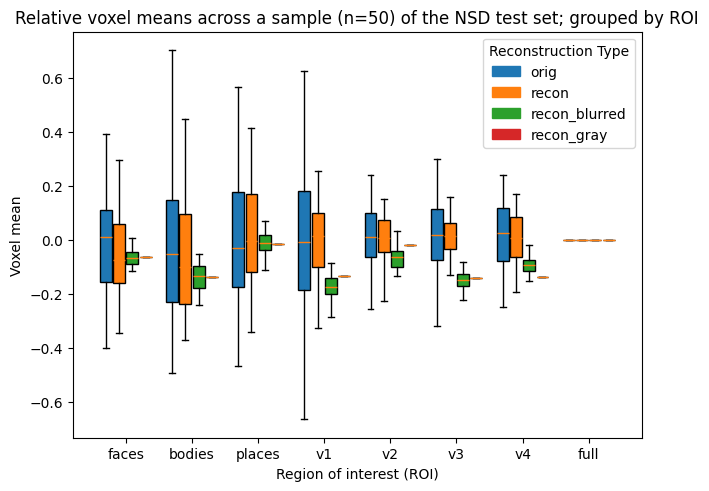

In [35]:
plot_grouped_boxplot(df_relative, "Relative voxel means across a sample (n=50) of the NSD test set; grouped by ROI")

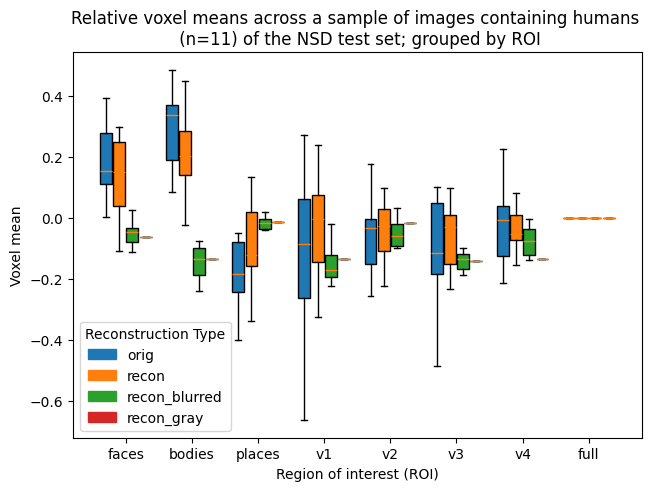

In [36]:
plot_grouped_boxplot(df_relative.loc[human_indices_df], "Relative voxel means across a sample of images containing humans \n (n=11) of the NSD test set; grouped by ROI")

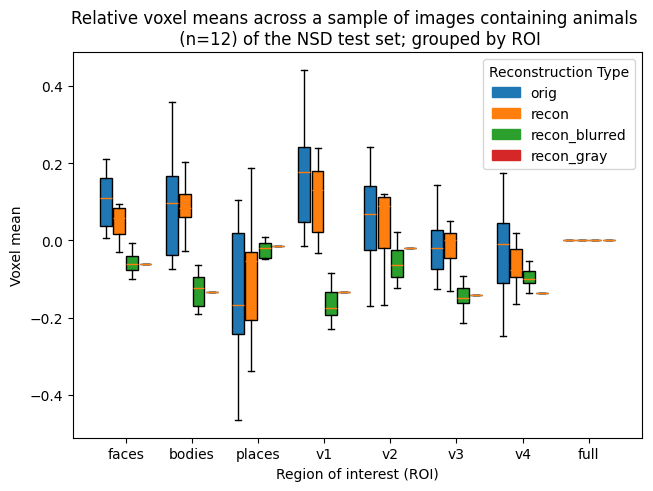

In [37]:
plot_grouped_boxplot(df_relative.loc[animal_indices_df], "Relative voxel means across a sample of images containing animals \n (n=12) of the NSD test set; grouped by ROI")

In [6]:
sample_means = torch.stack([fmri_recon[i].mean() for i in range(fmri_recon.shape[0])])
blurred_means = torch.stack([fmri_recon_blurred[i].mean() for i in range(fmri_recon_blurred.shape[0])])

sample_means, blurred_means

(tensor([ 0.0028, -0.0472, -0.0460, -0.0720, -0.1415,  0.0647,  0.0142,  0.0043,
          0.0237,  0.1077,  0.0972, -0.0619, -0.0426, -0.0942, -0.0966, -0.0904,
          0.0679, -0.0098, -0.1444, -0.1718,  0.0211, -0.1003, -0.3031, -0.1011,
          0.1070, -0.0965, -0.0314, -0.1855, -0.0378,  0.1034,  0.2179, -0.0147,
         -0.0254,  0.0768, -0.1791, -0.0986,  0.0196, -0.1513,  0.0472, -0.0083,
          0.1932,  0.1713,  0.0133,  0.0533, -0.0484, -0.0434, -0.0012,  0.0486,
         -0.1222,  0.0866]),
 tensor([-0.4334, -0.4504, -0.3682, -0.4130, -0.3517, -0.3411, -0.4476, -0.3128,
         -0.5597, -0.2857, -0.3480, -0.4771, -0.4769, -0.3024, -0.3935, -0.5209,
         -0.4352, -0.3065, -0.3631, -0.4411, -0.3091, -0.3553, -0.4202, -0.3868,
         -0.4362, -0.4240, -0.4272, -0.3571, -0.3271, -0.4991, -0.2487, -0.4093,
         -0.3732, -0.4258, -0.4983, -0.4144, -0.4591, -0.2558, -0.3867, -0.5361,
         -0.3862, -0.3213, -0.3748, -0.5042, -0.5033, -0.4526, -0.3982, -0.3142,

In [7]:
sample_means.mean(), blurred_means.mean()

(tensor(-0.0205), tensor(-0.4011))

In [ ]:
def masked_mean(tensor, mask):
    return (tensor * mask).sum() / mask.sum()

def masked_mean_absolute(tensor, mask):
    return torch.abs(tensor * mask).sum() / mask.sum()

def mse_to_orig(tensor, orig, mask):
    return (((tensor - orig) * mask) ** 2).sum() / mask.sum()

target = masked_mean

print(f"sample mean: {fmri_recon.abs().mean()}, blurred mean: {fmri_recon_blurred.abs().mean()}")

for key, mask in masks.items():
    target_means = torch.stack([target(fmri_recon[i], mask) for i in range(fmri_recon.shape[0])])
    target_means_blurred = torch.stack([target(fmri_recon_blurred[i], mask) for i in range(fmri_recon_blurred.shape[0])])
    print(f"{key} - target: {target_means.mean(): .4f} ({target_means.std(): .4f}), target blurred: {target_means_blurred.mean(): .4f} ({target_means_blurred.std(): .4f})")

sample mean: 0.24754676222801208, blurred mean: 0.45859116315841675
faces - target: -0.0697 ( 0.1621), target blurred: -0.4641 ( 0.0869)
bodies - target: -0.0774 ( 0.2133), target blurred: -0.5365 ( 0.0919)
places - target:  0.0075 ( 0.2265), target blurred: -0.4082 ( 0.0807)
v1 - target: -0.0255 ( 0.1921), target blurred: -0.5678 ( 0.0982)
v2 - target: -0.0172 ( 0.1461), target blurred: -0.4665 ( 0.0807)
v3 - target: -0.0175 ( 0.1607), target blurred: -0.5521 ( 0.0927)
v4 - target: -0.0160 ( 0.1640), target blurred: -0.4885 ( 0.0993)


In [16]:
for key, mask in masks.items():
    mse_s = [mse_to_orig(fmri_recon[i], fmri_orig[0], mask) for i in range(fmri_recon.shape[0])]
    mse_s_blurred = [mse_to_orig(fmri_recon_blurred[i], fmri_orig[0], mask) for i in range(fmri_recon_blurred.shape[0])]
    print(f"{key} - mse: {torch.tensor(mse_s).mean(): .4f} ({torch.tensor(mse_s).std(): .4f})")
    print(f"{key} - mse_blurred: {torch.tensor(mse_s_blurred).mean(): .4f} ({torch.tensor(mse_s_blurred).std(): .4f})")


faces - mse:  0.5618 ( 0.1181)
faces - mse_blurred:  0.5037 ( 0.0544)
bodies - mse:  0.4569 ( 0.1022)
bodies - mse_blurred:  0.6919 ( 0.1149)
places - mse:  0.4679 ( 0.0965)
places - mse_blurred:  0.4847 ( 0.0568)
v1 - mse:  0.9534 ( 0.2728)
v1 - mse_blurred:  0.4221 ( 0.0362)
v2 - mse:  0.9631 ( 0.2356)
v2 - mse_blurred:  0.3901 ( 0.0446)
v3 - mse:  1.0559 ( 0.2569)
v3 - mse_blurred:  0.4333 ( 0.0476)
v4 - mse:  0.8405 ( 0.2130)
v4 - mse_blurred:  0.4762 ( 0.0396)
full - mse:  0.6412 ( 0.1316)
full - mse_blurred:  0.4639 ( 0.0321)


We observe constant negative means for our baselines with low semantic content. Does this mean, that, due to CLIP-based training, the model forces the fMRI reconstructions to be soly linked to semantic content, completety disregarding the visual nature of the images?

In [2]:
attrib = torch.load("/u/fdammeier/artifacts/full_inference_20260917_121532_f4a88b/attributions.pt")

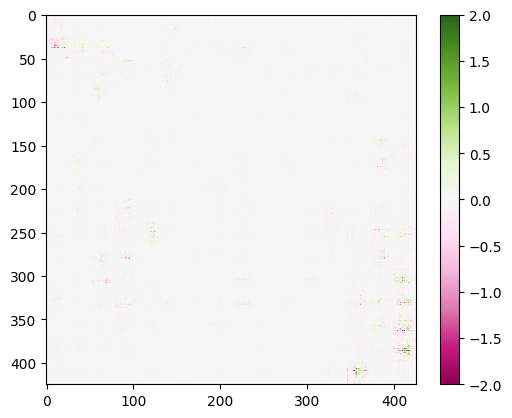

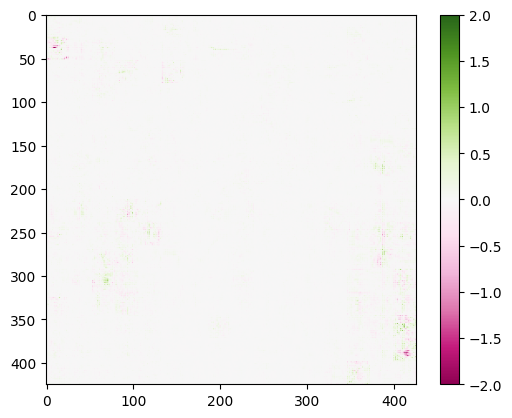

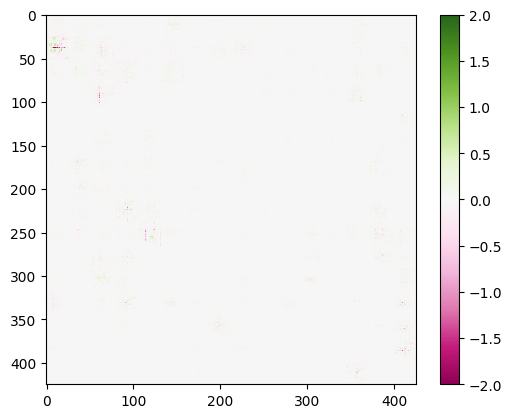

In [3]:
for i in [0, 1, 2]:
    plt.imshow(attrib[0, i, :, :]*100, vmin=-2, vmax=2, cmap='PiYG')
    plt.colorbar()
    plt.show()

In [10]:
# deltas
for baseline in ['blur', 'gray']:
    for n_iter in [50, 100]:
        delta = torch.load(f"/u/fdammeier/artifacts/integrated_gradients_{baseline}_{n_iter}/delta.pt")
        delta = delta.numpy().sum()
        print(f"Baseline: {baseline}, Iterations: {n_iter}, Delta: {delta:.4f}")

Baseline: blur, Iterations: 50, Delta: 0.4109
Baseline: blur, Iterations: 100, Delta: -0.1997
Baseline: gray, Iterations: 50, Delta: -1.5502
Baseline: gray, Iterations: 100, Delta: -0.0663


In [11]:
masked_mean = torch.load("/u/fdammeier/artifacts/integrated_gradients_blur_100/masked_mean.pt")

In [12]:
masked_mean

tensor([[0.0594]])

In [35]:
fmri_recon = torch.load("/u/fdammeier/artifacts/image_occlusion_original/reconstructed_fmri.pt")

fmri_recon.shape

torch.Size([7, 1, 15724])

In [37]:
mask_bodies = torch.load("/u/fdammeier/repositories/NeuroFlow/experiments/integrated_gradients/2d_masks/subject_1/mask_bodies.pt")

In [36]:
fmri_recon[1]

tensor([[0.3461, 0.6341, 0.7247,  ..., 0.1434, 0.6604, 0.5841]])

In [38]:
# test image index 90
fmri_sample_90 = fmri_recon[1]

In [40]:
fmri_sample_90.shape, mask_bodies.shape

(torch.Size([1, 15724]), torch.Size([1, 1, 15724]))

In [41]:
sample = fmri_sample_90.reshape(fmri_sample_90.shape[-1])
mask = mask_bodies.reshape(mask_bodies.shape[-1])

In [42]:
sample.shape, mask.shape

(torch.Size([15724]), torch.Size([15724]))

In [43]:
masked = sample * mask

In [46]:
masked.mean(), masked[masked > 0].mean(), masked[masked < 0].mean()

(tensor(0.0116), tensor(0.3293), tensor(-0.2681))